In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
simulaciones = pd.read_json("simulation.jsonlines", lines=True)
planes = pd.read_json("plans.jsonlines", lines=True)

# Analizando las simulaciones

In [2]:
simulaciones

,eventDescription,eventTime,eventType,simulationId,truckId
0,"(plaza del Dos de Mayo, 6, Madrid, [-3.7041862...",5760,Truck departed,a2bfd344-3b14-462a-82e7-d42aca54a650,1669HSZ
1,"(plaza del Dos de Mayo, 6, Madrid, [-3.7041862...",5730,Truck departed,a2bfd344-3b14-462a-82e7-d42aca54a650,8809GPH
2,"(plaza del Dos de Mayo, 6, Madrid, [-3.7041862...",5730,Truck departed,a2bfd344-3b14-462a-82e7-d42aca54a650,1161GJN
3,"(plaza del Dos de Mayo, 6, Madrid, [-3.7041862...",5430,Truck departed,a2bfd344-3b14-462a-82e7-d42aca54a650,3321FBL
4,"(plaza del Dos de Mayo, 6, Madrid, [-3.7041862...",5310,Truck departed,a2bfd344-3b14-462a-82e7-d42aca54a650,2423VRT
...,...,...,...,...,...
26577,"(calle de Juan de Austria, 1, Madrid, [-3.6991...",11562780,Truck arrived,f0f90050-5a0f-4965-864e-d6bc0d02b5a0,8386WZB
26578,"Packet 83 to (calle de Juan de Austria, 1, Mad...",11623380,Truck ended delivering,f0f90050-5a0f-4965-864e-d6bc0d02b5a0,8386WZB
26579,"(plaza del Dos de Mayo, 6, Madrid, [-3.7041862...",11623470,Truck departed to depot,f0f90050-5a0f-4965-864e-d6bc0d02b5a0,8386WZB
26580,,11813550,Truck ended route,f0f90050-5a0f-4965-864e-d6bc0d02b5a0,8386WZB


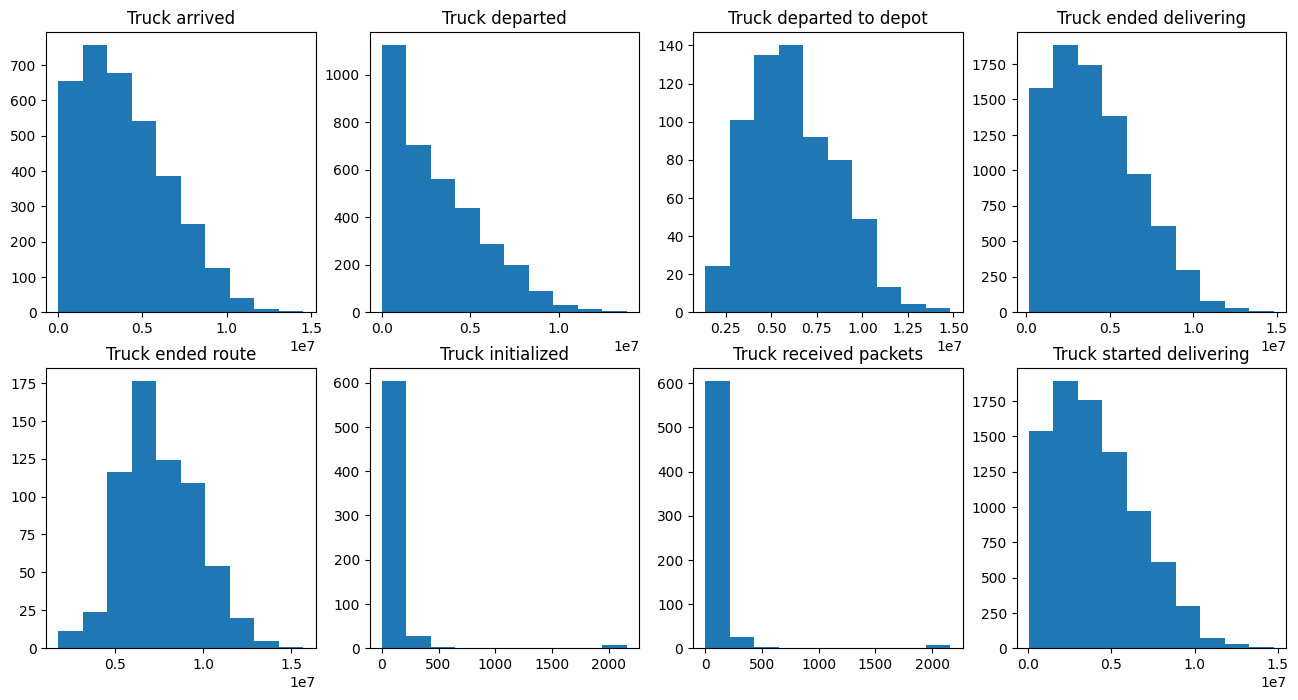

In [3]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for ax, (i, lista) in zip(axes,simulaciones.groupby("eventType").eventTime.agg(list).items()): #Ver como se distribuyen los tiempos para cada tipo de evento
    ax.hist(lista)
    ax.set_title(i)

In [4]:
simulaciones.groupby("eventType").eventTime.describe() #Ver estadísticas de cada tipo de evento

,count,mean,std,min,25%,50%,75%,max
eventType,,,,,,,,
Truck arrived,3444.0,3.972448e+06,2.569578e+06,30390.0,1874955.0,3596520.0,5648617.5,14530650.0
Truck departed,3444.0,3.040994e+06,2.601769e+06,360.0,918802.5,2548395.0,4676280.0,13838100.0
Truck departed to depot,640.0,6.232325e+06,2.332695e+06,1378410.0,4431705.0,5952045.0,7906027.5,14833350.0
Truck ended delivering,8567.0,4.147040e+06,2.558345e+06,150990.0,2055330.0,3779940.0,5826135.0,14833050.0
Truck ended route,640.0,7.535140e+06,2.157122e+06,1768530.0,5994165.0,7287840.0,9032520.0,15683250.0
Truck initialized,640.0,1.012969e+02,2.281717e+02,0.0,30.0,60.0,90.0,2160.0
Truck received packets,640.0,9.539062e+01,2.256020e+02,0.0,30.0,60.0,90.0,2160.0
Truck started delivering,8567.0,4.056088e+06,2.558056e+06,30390.0,1965825.0,3690420.0,5736705.0,14772420.0


In [5]:
lista_a_cambiar = ["Truck arrived","Truck departed","Truck departed to depot","Truck ended delivering","Truck ended route","Truck started delivering"]

In [6]:
simulaciones = simulaciones.join(simulaciones[simulaciones.eventType.isin(lista_a_cambiar)].eventTime.apply(lambda x: x/1000 if x>7*1e04 else x), rsuffix="_seg")
simulaciones["eventTime_seg"] = simulaciones.eventTime_seg.fillna(simulaciones["eventTime"])

In [7]:
simulaciones.groupby("eventType").eventTime_seg.describe()

,count,mean,std,min,25%,50%,75%,max
eventType,,,,,,,,
Truck arrived,3444.0,3991.044364,2655.763793,71.16,1880.7825,3603.405,5651.0775,33720.00
Truck departed,3444.0,3285.513876,2374.882101,155.73,1350.0000,2611.830,4697.6625,13838.10
Truck departed to depot,640.0,6232.325484,2332.695379,1378.41,4431.7050,5952.045,7906.0275,14833.35
Truck ended delivering,8567.0,4147.039855,2558.344796,150.99,2055.3300,3779.940,5826.1350,14833.05
Truck ended route,640.0,7535.140219,2157.121999,1768.53,5994.1650,7287.840,9032.5200,15683.25
Truck initialized,640.0,101.296875,228.171694,0.00,30.0000,60.000,90.0000,2160.00
Truck received packets,640.0,95.390625,225.601968,0.00,30.0000,60.000,90.0000,2160.00
Truck started delivering,8567.0,4063.567679,2593.011091,71.16,1968.6450,3694.320,5740.2600,33750.00


In [8]:
simulaciones = simulaciones.drop("eventTime", axis=1)

In [9]:
simulaciones

,eventDescription,eventType,simulationId,truckId,eventTime_seg
0,"(plaza del Dos de Mayo, 6, Madrid, [-3.7041862...",Truck departed,a2bfd344-3b14-462a-82e7-d42aca54a650,1669HSZ,5760.00
1,"(plaza del Dos de Mayo, 6, Madrid, [-3.7041862...",Truck departed,a2bfd344-3b14-462a-82e7-d42aca54a650,8809GPH,5730.00
2,"(plaza del Dos de Mayo, 6, Madrid, [-3.7041862...",Truck departed,a2bfd344-3b14-462a-82e7-d42aca54a650,1161GJN,5730.00
3,"(plaza del Dos de Mayo, 6, Madrid, [-3.7041862...",Truck departed,a2bfd344-3b14-462a-82e7-d42aca54a650,3321FBL,5430.00
4,"(plaza del Dos de Mayo, 6, Madrid, [-3.7041862...",Truck departed,a2bfd344-3b14-462a-82e7-d42aca54a650,2423VRT,5310.00
...,...,...,...,...,...
26577,"(calle de Juan de Austria, 1, Madrid, [-3.6991...",Truck arrived,f0f90050-5a0f-4965-864e-d6bc0d02b5a0,8386WZB,11562.78
26578,"Packet 83 to (calle de Juan de Austria, 1, Mad...",Truck ended delivering,f0f90050-5a0f-4965-864e-d6bc0d02b5a0,8386WZB,11623.38
26579,"(plaza del Dos de Mayo, 6, Madrid, [-3.7041862...",Truck departed to depot,f0f90050-5a0f-4965-864e-d6bc0d02b5a0,8386WZB,11623.47
26580,,Truck ended route,f0f90050-5a0f-4965-864e-d6bc0d02b5a0,8386WZB,11813.55


# Analizando los planes

In [10]:
planes = planes.join(planes.trucks.explode().apply(pd.Series), lsuffix='_sim').reset_index(drop=True)
planes

,items_sim,simulationId,trucks,items,route,truck_id
0,"[{'itemId': '0', 'locationId': '326ae8dc7810de...",a2bfd344-3b14-462a-82e7-d42aca54a650,"[{'items': ['23', '24', '4', '25', '26', '27',...","[23, 24, 4, 25, 26, 27, 28, 40, 41, 42, 43, 13...","[{'destination': 'af3ea5c0e98151a51bd39c64', '...",5534TPH
1,"[{'itemId': '0', 'locationId': '326ae8dc7810de...",a2bfd344-3b14-462a-82e7-d42aca54a650,"[{'items': ['23', '24', '4', '25', '26', '27',...","[74, 75, 76, 67, 68, 69, 70, 92, 93, 94, 55, 5...","[{'destination': 'faf06210580833f8c7963506', '...",2423VRT
2,"[{'itemId': '0', 'locationId': '326ae8dc7810de...",a2bfd344-3b14-462a-82e7-d42aca54a650,"[{'items': ['23', '24', '4', '25', '26', '27',...","[18, 19, 57, 58, 88, 89, 90, 91, 54, 20, 21, 2...","[{'destination': 'bef2df0471ee1c26b4ab6ba9', '...",0265TYL
3,"[{'itemId': '0', 'locationId': '326ae8dc7810de...",a2bfd344-3b14-462a-82e7-d42aca54a650,"[{'items': ['23', '24', '4', '25', '26', '27',...","[87, 0, 1, 2, 3, 33, 95, 96, 97]","[{'destination': '7a249403ad22a72495769f75', '...",8809GPH
4,"[{'itemId': '0', 'locationId': '326ae8dc7810de...",a2bfd344-3b14-462a-82e7-d42aca54a650,"[{'items': ['23', '24', '4', '25', '26', '27',...","[31, 32, 37, 38, 39, 66]","[{'destination': '1e38734ff239ccf75bf04b95', '...",1161GJN
...,...,...,...,...,...,...
635,"[{'itemId': '0', 'locationId': 'd1214b27823e6d...",6deec7b7-6c11-418c-a1bd-f99a9e3261b6,"[{'items': ['53', '54', '55', '83', '84', '85'...","[53, 54, 55, 83, 84, 85, 86, 26, 27, 29, 30, 3...","[{'destination': '225cd814768e8ca390983313', '...",5534TPH
636,"[{'itemId': '0', 'locationId': 'd1214b27823e6d...",6deec7b7-6c11-418c-a1bd-f99a9e3261b6,"[{'items': ['53', '54', '55', '83', '84', '85'...","[72, 73, 74, 88, 89, 90, 91, 43, 62, 63, 64, 3...","[{'destination': '417bf3aae83127cd905f3bc9', '...",3953RLD
637,"[{'itemId': '0', 'locationId': 'd1214b27823e6d...",6deec7b7-6c11-418c-a1bd-f99a9e3261b6,"[{'items': ['53', '54', '55', '83', '84', '85'...","[6, 7, 8, 9]","[{'destination': '1e1251e186dd507f63e4d1e6', '...",5030LXK
638,"[{'itemId': '0', 'locationId': 'd1214b27823e6d...",6deec7b7-6c11-418c-a1bd-f99a9e3261b6,"[{'items': ['53', '54', '55', '83', '84', '85'...","[44, 45, 46, 47, 94, 20, 21, 22, 95, 96, 97, 6...","[{'destination': '6a33d0bcd3624ccb86febf09', '...",3321FBL


In [11]:
planes = planes.join(planes.route.explode().apply(pd.Series), lsuffix='_sim').reset_index(drop=True)
planes

,items_sim,simulationId,trucks,items,route,truck_id,destination,duration,origin
0,"[{'itemId': '0', 'locationId': '326ae8dc7810de...",a2bfd344-3b14-462a-82e7-d42aca54a650,"[{'items': ['23', '24', '4', '25', '26', '27',...","[23, 24, 4, 25, 26, 27, 28, 40, 41, 42, 43, 13...","[{'destination': 'af3ea5c0e98151a51bd39c64', '...",5534TPH,af3ea5c0e98151a51bd39c64,197,ce6feed06bc1a9e5aff95f04
1,"[{'itemId': '0', 'locationId': '326ae8dc7810de...",a2bfd344-3b14-462a-82e7-d42aca54a650,"[{'items': ['23', '24', '4', '25', '26', '27',...","[23, 24, 4, 25, 26, 27, 28, 40, 41, 42, 43, 13...","[{'destination': 'af3ea5c0e98151a51bd39c64', '...",5534TPH,c0430d1e19c34a06e343a270,733,af3ea5c0e98151a51bd39c64
2,"[{'itemId': '0', 'locationId': '326ae8dc7810de...",a2bfd344-3b14-462a-82e7-d42aca54a650,"[{'items': ['23', '24', '4', '25', '26', '27',...","[23, 24, 4, 25, 26, 27, 28, 40, 41, 42, 43, 13...","[{'destination': 'af3ea5c0e98151a51bd39c64', '...",5534TPH,b31f6bb5c55435cb5495a62b,380,c0430d1e19c34a06e343a270
3,"[{'itemId': '0', 'locationId': '326ae8dc7810de...",a2bfd344-3b14-462a-82e7-d42aca54a650,"[{'items': ['23', '24', '4', '25', '26', '27',...","[23, 24, 4, 25, 26, 27, 28, 40, 41, 42, 43, 13...","[{'destination': 'af3ea5c0e98151a51bd39c64', '...",5534TPH,58a50ddf91095c052e330fd6,612,b31f6bb5c55435cb5495a62b
4,"[{'itemId': '0', 'locationId': '326ae8dc7810de...",a2bfd344-3b14-462a-82e7-d42aca54a650,"[{'items': ['23', '24', '4', '25', '26', '27',...","[23, 24, 4, 25, 26, 27, 28, 40, 41, 42, 43, 13...","[{'destination': 'af3ea5c0e98151a51bd39c64', '...",5534TPH,910cd4ad38bc68ff7abdd941,850,58a50ddf91095c052e330fd6
...,...,...,...,...,...,...,...,...,...
4079,"[{'itemId': '0', 'locationId': 'd1214b27823e6d...",6deec7b7-6c11-418c-a1bd-f99a9e3261b6,"[{'items': ['53', '54', '55', '83', '84', '85'...","[79, 80, 81, 82, 24, 25, 40, 41, 42, 12, 23, 9...","[{'destination': '17c23e21622baec6f08861dd', '...",6270NFM,5bec37aee4796cc965e71c88,1173,20ee036e147b4a1bd5af0e1c
4080,"[{'itemId': '0', 'locationId': 'd1214b27823e6d...",6deec7b7-6c11-418c-a1bd-f99a9e3261b6,"[{'items': ['53', '54', '55', '83', '84', '85'...","[79, 80, 81, 82, 24, 25, 40, 41, 42, 12, 23, 9...","[{'destination': '17c23e21622baec6f08861dd', '...",6270NFM,1f183bd64aa5bfae47843de5,1198,5bec37aee4796cc965e71c88
4081,"[{'itemId': '0', 'locationId': 'd1214b27823e6d...",6deec7b7-6c11-418c-a1bd-f99a9e3261b6,"[{'items': ['53', '54', '55', '83', '84', '85'...","[79, 80, 81, 82, 24, 25, 40, 41, 42, 12, 23, 9...","[{'destination': '17c23e21622baec6f08861dd', '...",6270NFM,4551fdc303a5ddafa1dcf28c,1133,1f183bd64aa5bfae47843de5
4082,"[{'itemId': '0', 'locationId': 'd1214b27823e6d...",6deec7b7-6c11-418c-a1bd-f99a9e3261b6,"[{'items': ['53', '54', '55', '83', '84', '85'...","[79, 80, 81, 82, 24, 25, 40, 41, 42, 12, 23, 9...","[{'destination': '17c23e21622baec6f08861dd', '...",6270NFM,2884f6b369dc20f3051a216d,804,4551fdc303a5ddafa1dcf28c


# Uniendo los dos dataframes

In [12]:
simulaciones.shape

(26582, 5)

In [13]:
planes.shape

(4084, 9)

Los planes son iguales a la suma de "Truck arrive" y "Truck ended route"

In [14]:
simulaciones.groupby("eventType").count()

,eventDescription,simulationId,truckId,eventTime_seg
eventType,,,,
Truck arrived,3444,3444,3444,3444
Truck departed,3444,3444,3444,3444
Truck departed to depot,640,640,640,640
Truck ended delivering,8567,8567,8567,8567
Truck ended route,640,640,640,640
Truck initialized,640,640,640,640
Truck received packets,640,640,640,640
Truck started delivering,8567,8567,8567,8567


In [15]:
simulaciones_viajes = simulaciones[(simulaciones["eventType"].isin(["Truck arrived","Truck initialized"]))].copy()

In [16]:
simulaciones_viajes = simulaciones_viajes.rename(columns={"truckId":"truck_id"})

In [17]:
simulaciones_viajes_sorted = simulaciones_viajes.sort_values(["simulationId","truck_id","eventTime_seg"]).set_index(["simulationId","truck_id"]).copy()

In [18]:
planes_sorted = planes.sort_values(["simulationId","truck_id"]).set_index(["simulationId","truck_id"]).copy()

In [19]:
tiempoViaje = pd.concat([simulaciones_viajes_sorted,planes_sorted], axis=1).copy()

In [20]:
tiempoViaje = tiempoViaje.reset_index()

In [21]:
tiempoViaje.head()

,simulationId,truck_id,eventDescription,eventType,eventTime_seg,items_sim,trucks,items,route,destination,duration,origin
0,007f3d08-14a7-4a93-af9e-f0d9cfbcea94,3321FBL,,Truck initialized,90.00,"[{'itemId': '0', 'locationId': 'bc451e2cea161c...","[{'items': ['68', '69', '70', '53', '54', '55'...","[78, 79, 50, 51, 52, 23, 21, 58, 59, 60, 61, 4...","[{'destination': '2e8d1b7b9fad4f083892d83c', '...",2e8d1b7b9fad4f083892d83c,614,ce6feed06bc1a9e5aff95f04
1,007f3d08-14a7-4a93-af9e-f0d9cfbcea94,3321FBL,"(calle del Poeta Blas de Otero, 22, Madrid, [-...",Truck arrived,751.62,"[{'itemId': '0', 'locationId': 'bc451e2cea161c...","[{'items': ['68', '69', '70', '53', '54', '55'...","[78, 79, 50, 51, 52, 23, 21, 58, 59, 60, 61, 4...","[{'destination': '2e8d1b7b9fad4f083892d83c', '...",f5a3aab0c10fb7c5c60f2b01,397,2e8d1b7b9fad4f083892d83c
2,007f3d08-14a7-4a93-af9e-f0d9cfbcea94,3321FBL,"(calle de Valdecanillas, 59, Madrid, [-3.62356...",Truck arrived,1475.52,"[{'itemId': '0', 'locationId': 'bc451e2cea161c...","[{'items': ['68', '69', '70', '53', '54', '55'...","[78, 79, 50, 51, 52, 23, 21, 58, 59, 60, 61, 4...","[{'destination': '2e8d1b7b9fad4f083892d83c', '...",4b5f692a806a39d1317d15d4,259,f5a3aab0c10fb7c5c60f2b01
3,007f3d08-14a7-4a93-af9e-f0d9cfbcea94,3321FBL,"(avda de la Institución Libre de Enseñanza, 19...",Truck arrived,1969.32,"[{'itemId': '0', 'locationId': 'bc451e2cea161c...","[{'items': ['68', '69', '70', '53', '54', '55'...","[78, 79, 50, 51, 52, 23, 21, 58, 59, 60, 61, 4...","[{'destination': '2e8d1b7b9fad4f083892d83c', '...",64bba266de127a5949f52d9a,349,4b5f692a806a39d1317d15d4
4,007f3d08-14a7-4a93-af9e-f0d9cfbcea94,3321FBL,"(bulev de José Prat, 5, Madrid, [-3.6233859044...",Truck arrived,2508.72,"[{'itemId': '0', 'locationId': 'bc451e2cea161c...","[{'items': ['68', '69', '70', '53', '54', '55'...","[78, 79, 50, 51, 52, 23, 21, 58, 59, 60, 61, 4...","[{'destination': '2e8d1b7b9fad4f083892d83c', '...",6942f2624e971761b7dd9208,384,64bba266de127a5949f52d9a


In [22]:
def tiempo_sim(evento):
    return [j-i for i, j in zip(evento[:-1], evento[1:])]

In [23]:
tiempoViaje["eventTime_entre"]=tiempoViaje.groupby(["simulationId","truck_id"]).eventTime_seg.agg(list).apply(lambda x: tiempo_sim(x)).apply(lambda x: np.append(x,np.nan)).explode().apply(pd.Series).reset_index()[0]

In [24]:
tiempoViaje["eventTime_entre"] = tiempoViaje.eventTime_entre.fillna(tiempoViaje["eventTime_seg"])

In [25]:
tiempoViaje["nItems"] = tiempoViaje["items"].apply(lambda x: len(x))
tiempoViaje["nParadas"] = tiempoViaje["route"].apply(lambda x: len(x))

In [26]:
from sklearn.preprocessing import LabelEncoder

In [27]:
encoder = LabelEncoder()

In [28]:
tiempoViaje["matriculasCodificadas"] = pd.Series(encoder.fit_transform(tiempoViaje.truck_id))

In [29]:
tiempoViaje["destinosCodificados"] = pd.Series(encoder.fit_transform(tiempoViaje.destination))
tiempoViaje["origenesCodificados"] = pd.Series(encoder.fit_transform(tiempoViaje.origin))

In [43]:
def tiempo_acumulado(evento):
    return [np.sum(evento[:i+1]) for i in range(len(evento))]

In [46]:
tiempoViaje["tiempoacumulado_plan"] = tiempoViaje.groupby(["simulationId","truck_id"]).duration.agg(list).apply(lambda x: tiempo_acumulado(x)).explode().apply(pd.Series).reset_index()[0]

In [47]:
tiempoViaje

,simulationId,truck_id,eventDescription,eventType,eventTime_seg,items_sim,trucks,items,route,destination,duration,origin,eventTime_entre,nItems,nParadas,matriculasCodificadas,destinosCodificados,origenesCodificados,tiempoacumulado_plan
0,007f3d08-14a7-4a93-af9e-f0d9cfbcea94,3321FBL,,Truck initialized,90.00,"[{'itemId': '0', 'locationId': 'bc451e2cea161c...","[{'items': ['68', '69', '70', '53', '54', '55'...","[78, 79, 50, 51, 52, 23, 21, 58, 59, 60, 61, 4...","[{'destination': '2e8d1b7b9fad4f083892d83c', '...",2e8d1b7b9fad4f083892d83c,614,ce6feed06bc1a9e5aff95f04,661.62,26,15,9,357,1615,614
1,007f3d08-14a7-4a93-af9e-f0d9cfbcea94,3321FBL,"(calle del Poeta Blas de Otero, 22, Madrid, [-...",Truck arrived,751.62,"[{'itemId': '0', 'locationId': 'bc451e2cea161c...","[{'items': ['68', '69', '70', '53', '54', '55'...","[78, 79, 50, 51, 52, 23, 21, 58, 59, 60, 61, 4...","[{'destination': '2e8d1b7b9fad4f083892d83c', '...",f5a3aab0c10fb7c5c60f2b01,397,2e8d1b7b9fad4f083892d83c,723.90,26,15,9,1910,357,1011
2,007f3d08-14a7-4a93-af9e-f0d9cfbcea94,3321FBL,"(calle de Valdecanillas, 59, Madrid, [-3.62356...",Truck arrived,1475.52,"[{'itemId': '0', 'locationId': 'bc451e2cea161c...","[{'items': ['68', '69', '70', '53', '54', '55'...","[78, 79, 50, 51, 52, 23, 21, 58, 59, 60, 61, 4...","[{'destination': '2e8d1b7b9fad4f083892d83c', '...",4b5f692a806a39d1317d15d4,259,f5a3aab0c10fb7c5c60f2b01,493.80,26,15,9,596,1910,1270
3,007f3d08-14a7-4a93-af9e-f0d9cfbcea94,3321FBL,"(avda de la Institución Libre de Enseñanza, 19...",Truck arrived,1969.32,"[{'itemId': '0', 'locationId': 'bc451e2cea161c...","[{'items': ['68', '69', '70', '53', '54', '55'...","[78, 79, 50, 51, 52, 23, 21, 58, 59, 60, 61, 4...","[{'destination': '2e8d1b7b9fad4f083892d83c', '...",64bba266de127a5949f52d9a,349,4b5f692a806a39d1317d15d4,539.40,26,15,9,788,596,1619
4,007f3d08-14a7-4a93-af9e-f0d9cfbcea94,3321FBL,"(bulev de José Prat, 5, Madrid, [-3.6233859044...",Truck arrived,2508.72,"[{'itemId': '0', 'locationId': 'bc451e2cea161c...","[{'items': ['68', '69', '70', '53', '54', '55'...","[78, 79, 50, 51, 52, 23, 21, 58, 59, 60, 61, 4...","[{'destination': '2e8d1b7b9fad4f083892d83c', '...",6942f2624e971761b7dd9208,384,64bba266de127a5949f52d9a,579.60,26,15,9,828,788,2003
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4079,fea13535-ade6-4215-96ca-dab5b4ef309b,6965XLY,"(calle Luis Madrona, S/N, Alcalá de Henares, [...",Truck arrived,2697.81,"[{'itemId': '0', 'locationId': '17d843cfd0ff57...","[{'items': ['61', '62', '63', '11', '12', '13'...","[15, 44, 45, 46, 47, 22, 23, 24, 2, 3, 40, 41,...","[{'destination': '58bb022022a0e97ef0efcf46', '...",92e059821c9ca8b3967bece4,157,fb28b93228a49e10f73abd62,561.27,17,7,14,1144,1953,2202
4080,fea13535-ade6-4215-96ca-dab5b4ef309b,6965XLY,"(calle Marqués de Alonso Martínez, 9, Alcalá d...",Truck arrived,3259.08,"[{'itemId': '0', 'locationId': '17d843cfd0ff57...","[{'items': ['61', '62', '63', '11', '12', '13'...","[15, 44, 45, 46, 47, 22, 23, 24, 2, 3, 40, 41,...","[{'destination': '58bb022022a0e97ef0efcf46', '...",1f9012c136c055e10f9ef9cb,300,92e059821c9ca8b3967bece4,674.40,17,7,14,230,1144,2502
4081,fea13535-ade6-4215-96ca-dab5b4ef309b,6965XLY,"(calle San Vidal, 24, Alcalá de Henares, [-3.3...",Truck arrived,3933.48,"[{'itemId': '0', 'locationId': '17d843cfd0ff57...","[{'items': ['61', '62', '63', '11', '12', '13'...","[15, 44, 45, 46, 47, 22, 23, 24, 2, 3, 40, 41,...","[{'destination': '58bb022022a0e97ef0efcf46', '...",0efbacc39472a86ca3de1b21,2620,1f9012c136c055e10f9ef9cb,3390.30,17,7,14,101,230,5122
4082,fea13535-ade6-4215-96ca-dab5b4ef309b,6965XLY,"(calle de la Comunidad de Madrid, 37, Rozas de...",Truck arrived,7323.78,"[{'itemId': '0', 'locationId': '17d843cfd0ff57...","[{'items': ['61', '62', '63', '11', '12', '13'...","[15, 44, 45, 46, 47, 22, 23, 24, 2, 3, 40, 41,...","[{'destination': '58bb022022a0e97ef0efcf46', '...",7658997164924eab18ea6e08,472,0efbacc39472a86ca3de1b21,859.20,17,7,14,923,101,5594


# Predicción tiempo de viaje

In [48]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LinearRegression

In [49]:
tiempoViaje.head()

,simulationId,truck_id,eventDescription,eventType,eventTime_seg,items_sim,trucks,items,route,destination,duration,origin,eventTime_entre,nItems,nParadas,matriculasCodificadas,destinosCodificados,origenesCodificados,tiempoacumulado_plan
0,007f3d08-14a7-4a93-af9e-f0d9cfbcea94,3321FBL,,Truck initialized,90.00,"[{'itemId': '0', 'locationId': 'bc451e2cea161c...","[{'items': ['68', '69', '70', '53', '54', '55'...","[78, 79, 50, 51, 52, 23, 21, 58, 59, 60, 61, 4...","[{'destination': '2e8d1b7b9fad4f083892d83c', '...",2e8d1b7b9fad4f083892d83c,614,ce6feed06bc1a9e5aff95f04,661.62,26,15,9,357,1615,614
1,007f3d08-14a7-4a93-af9e-f0d9cfbcea94,3321FBL,"(calle del Poeta Blas de Otero, 22, Madrid, [-...",Truck arrived,751.62,"[{'itemId': '0', 'locationId': 'bc451e2cea161c...","[{'items': ['68', '69', '70', '53', '54', '55'...","[78, 79, 50, 51, 52, 23, 21, 58, 59, 60, 61, 4...","[{'destination': '2e8d1b7b9fad4f083892d83c', '...",f5a3aab0c10fb7c5c60f2b01,397,2e8d1b7b9fad4f083892d83c,723.90,26,15,9,1910,357,1011
2,007f3d08-14a7-4a93-af9e-f0d9cfbcea94,3321FBL,"(calle de Valdecanillas, 59, Madrid, [-3.62356...",Truck arrived,1475.52,"[{'itemId': '0', 'locationId': 'bc451e2cea161c...","[{'items': ['68', '69', '70', '53', '54', '55'...","[78, 79, 50, 51, 52, 23, 21, 58, 59, 60, 61, 4...","[{'destination': '2e8d1b7b9fad4f083892d83c', '...",4b5f692a806a39d1317d15d4,259,f5a3aab0c10fb7c5c60f2b01,493.80,26,15,9,596,1910,1270
3,007f3d08-14a7-4a93-af9e-f0d9cfbcea94,3321FBL,"(avda de la Institución Libre de Enseñanza, 19...",Truck arrived,1969.32,"[{'itemId': '0', 'locationId': 'bc451e2cea161c...","[{'items': ['68', '69', '70', '53', '54', '55'...","[78, 79, 50, 51, 52, 23, 21, 58, 59, 60, 61, 4...","[{'destination': '2e8d1b7b9fad4f083892d83c', '...",64bba266de127a5949f52d9a,349,4b5f692a806a39d1317d15d4,539.40,26,15,9,788,596,1619
4,007f3d08-14a7-4a93-af9e-f0d9cfbcea94,3321FBL,"(bulev de José Prat, 5, Madrid, [-3.6233859044...",Truck arrived,2508.72,"[{'itemId': '0', 'locationId': 'bc451e2cea161c...","[{'items': ['68', '69', '70', '53', '54', '55'...","[78, 79, 50, 51, 52, 23, 21, 58, 59, 60, 61, 4...","[{'destination': '2e8d1b7b9fad4f083892d83c', '...",6942f2624e971761b7dd9208,384,64bba266de127a5949f52d9a,579.60,26,15,9,828,788,2003


In [51]:
# Cargar un dataset de ejemplo
# features = ["duration","eventTime_seg"]
features = ["duration","eventTime_seg","nItems","nParadas","matriculasCodificadas","destinosCodificados","origenesCodificados","tiempoacumulado_plan"]
X, y = tiempoViaje[features], tiempoViaje["eventTime_entre"]

# Dividir en conjunto de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Crear y entrenar el modelo
rf = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42)
rf.fit(X_train, y_train)

# Hacer predicciones
y_pred = rf.predict(X_test)

# Evaluar el modelo
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse) 

print(f"MAE: {mae:.4f}")
print(f"R² Score: {r2:.4f}")
print(f"MSE: {mse:.4f}")
print(f"RMSE: {rmse:.4f}")

MAE: 170.4455
R² Score: 0.7805
MSE: 1688142.8602
RMSE: 1299.2855


In [52]:
# Cargar un dataset de ejemplo
features = ["duration","eventTime_seg","nItems","nParadas","matriculasCodificadas","destinosCodificados","origenesCodificados","tiempoacumulado_plan"]
X, y = tiempoViaje[features], tiempoViaje["eventTime_entre"]

# Dividir en conjunto de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Crear y entrenar el modelo
lr = LinearRegression()
lr.fit(X_train, y_train)

# Hacer predicciones
y_pred = lr.predict(X_test)

# Evaluar el modelo
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse) 

print(f"MAE: {mae:.4f}")
print(f"R² Score: {r2:.4f}")
print(f"MSE: {mse:.4f}")
print(f"RMSE: {rmse:.4f}")


MAE: 1266.4297
R² Score: 0.5424
MSE: 3518876.6885
RMSE: 1875.8669


In [25]:
planes.trucks.explode().apply(pd.Series)[["items","route"]].apply(lambda x : pd.Series((len(x[0]),len(x[1]))), axis=1)

C:\Users\LIJUN\AppData\Local\Temp\ipykernel_4900\3607651732.py:1: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  planes.trucks.explode().apply(pd.Series)[["items","route"]].apply(lambda x : pd.Series((len(x[0]),len(x[1]))), axis=1)


,0,1
0,28,10
0,18,7
0,15,7
0,9,5
0,6,4
...,...,...
98,23,10
98,30,12
98,4,2
98,27,11


In [6]:
planes.trucks.explode().apply(pd.Series).route

0     [{'destination': 'af3ea5c0e98151a51bd39c64', '...
0     [{'destination': 'faf06210580833f8c7963506', '...
0     [{'destination': 'bef2df0471ee1c26b4ab6ba9', '...
0     [{'destination': '7a249403ad22a72495769f75', '...
0     [{'destination': '1e38734ff239ccf75bf04b95', '...
                            ...                        
98    [{'destination': '225cd814768e8ca390983313', '...
98    [{'destination': '417bf3aae83127cd905f3bc9', '...
98    [{'destination': '1e1251e186dd507f63e4d1e6', '...
98    [{'destination': '6a33d0bcd3624ccb86febf09', '...
98    [{'destination': '17c23e21622baec6f08861dd', '...
Name: route, Length: 640, dtype: object

In [7]:
planes.trucks.explode().apply(pd.Series).route.iloc[0]

[{'destination': 'af3ea5c0e98151a51bd39c64',
  'duration': 197,
  'origin': 'ce6feed06bc1a9e5aff95f04'},
 {'destination': 'c0430d1e19c34a06e343a270',
  'duration': 733,
  'origin': 'af3ea5c0e98151a51bd39c64'},
 {'destination': 'b31f6bb5c55435cb5495a62b',
  'duration': 380,
  'origin': 'c0430d1e19c34a06e343a270'},
 {'destination': '58a50ddf91095c052e330fd6',
  'duration': 612,
  'origin': 'b31f6bb5c55435cb5495a62b'},
 {'destination': '910cd4ad38bc68ff7abdd941',
  'duration': 850,
  'origin': '58a50ddf91095c052e330fd6'},
 {'destination': '49a09d201cc830dc1c4e87fc',
  'duration': 241,
  'origin': '910cd4ad38bc68ff7abdd941'},
 {'destination': '324beca4107779629830c6d3',
  'duration': 689,
  'origin': '49a09d201cc830dc1c4e87fc'},
 {'destination': '123039c250dd5a3e7c3e4fc8',
  'duration': 187,
  'origin': '324beca4107779629830c6d3'},
 {'destination': '5a13a4517d5fc3018de2dbea',
  'duration': 1203,
  'origin': '123039c250dd5a3e7c3e4fc8'},
 {'destination': 'ce6feed06bc1a9e5aff95f04',
  'durati

In [8]:
planes["items"].apply(lambda x : x[1])

0     {'itemId': '1', 'locationId': '326ae8dc7810de9...
1     {'itemId': '1', 'locationId': 'beb9ae6f854d9e3...
2     {'itemId': '1', 'locationId': '74157e26110a18d...
3     {'itemId': '1', 'locationId': '0078f3bf6db0921...
4     {'itemId': '1', 'locationId': '92e059821c9ca8b...
                            ...                        
94    {'itemId': '1', 'locationId': '281ec8ac82cccd8...
95    {'itemId': '1', 'locationId': '950001b613cb58c...
96    {'itemId': '1', 'locationId': 'b40599012e4fba1...
97    {'itemId': '1', 'locationId': '074dc13529fd8b1...
98    {'itemId': '1', 'locationId': 'd1214b27823e6dd...
Name: items, Length: 99, dtype: object

# Paso 2: Transformación de los datos

1. Aplico la función proporcionada en la página de Github

De este modo puedo ver con más claridad como están ordenados los datos, elimino la columna truck porque ya tenemos los datos en diferentes columnas.

In [35]:
planes = planes.join(planes.trucks.explode().apply(pd.Series), lsuffix='_sim').reset_index(drop=True).drop("trucks", axis=1)
planes

,items_sim,simulationId,items,route,truck_id
0,"[{'itemId': '0', 'locationId': '326ae8dc7810de...",a2bfd344-3b14-462a-82e7-d42aca54a650,"[23, 24, 4, 25, 26, 27, 28, 40, 41, 42, 43, 13...","[{'destination': 'af3ea5c0e98151a51bd39c64', '...",5534TPH
1,"[{'itemId': '0', 'locationId': '326ae8dc7810de...",a2bfd344-3b14-462a-82e7-d42aca54a650,"[74, 75, 76, 67, 68, 69, 70, 92, 93, 94, 55, 5...","[{'destination': 'faf06210580833f8c7963506', '...",2423VRT
2,"[{'itemId': '0', 'locationId': '326ae8dc7810de...",a2bfd344-3b14-462a-82e7-d42aca54a650,"[18, 19, 57, 58, 88, 89, 90, 91, 54, 20, 21, 2...","[{'destination': 'bef2df0471ee1c26b4ab6ba9', '...",0265TYL
3,"[{'itemId': '0', 'locationId': '326ae8dc7810de...",a2bfd344-3b14-462a-82e7-d42aca54a650,"[87, 0, 1, 2, 3, 33, 95, 96, 97]","[{'destination': '7a249403ad22a72495769f75', '...",8809GPH
4,"[{'itemId': '0', 'locationId': '326ae8dc7810de...",a2bfd344-3b14-462a-82e7-d42aca54a650,"[31, 32, 37, 38, 39, 66]","[{'destination': '1e38734ff239ccf75bf04b95', '...",1161GJN
...,...,...,...,...,...
635,"[{'itemId': '0', 'locationId': 'd1214b27823e6d...",6deec7b7-6c11-418c-a1bd-f99a9e3261b6,"[53, 54, 55, 83, 84, 85, 86, 26, 27, 29, 30, 3...","[{'destination': '225cd814768e8ca390983313', '...",5534TPH
636,"[{'itemId': '0', 'locationId': 'd1214b27823e6d...",6deec7b7-6c11-418c-a1bd-f99a9e3261b6,"[72, 73, 74, 88, 89, 90, 91, 43, 62, 63, 64, 3...","[{'destination': '417bf3aae83127cd905f3bc9', '...",3953RLD
637,"[{'itemId': '0', 'locationId': 'd1214b27823e6d...",6deec7b7-6c11-418c-a1bd-f99a9e3261b6,"[6, 7, 8, 9]","[{'destination': '1e1251e186dd507f63e4d1e6', '...",5030LXK
638,"[{'itemId': '0', 'locationId': 'd1214b27823e6d...",6deec7b7-6c11-418c-a1bd-f99a9e3261b6,"[44, 45, 46, 47, 94, 20, 21, 22, 95, 96, 97, 6...","[{'destination': '6a33d0bcd3624ccb86febf09', '...",3321FBL


In [36]:
planes = planes.groupby(["simulationId","truck_id"]).agg(list)

2. Ahora busco sacar información del dataframe de simulaciones

Observo que hay 8 tipos de eventos diferentes, "Truck departed" indica desde donde sale el camión al comienzo, "Truck initialized" indica cuando inicia el trabajo, "Truck received packets" indica la lista de paquetes indicando los paquetes y el lugar al que hay que enviarlos, "Truck arrived" indica a qué ubicación ha llegado, "Truck started delivering" indica el lugar al que está repartiendo y el paquete en concreto, "Truck ended delivering" indica cuándo ha terminado de repartir un paquete en concreto, "Truck departed to depot" indica el final de la jornada y "Truck ended route" indica que ha llegado al final de la ruta.

In [37]:
simulaciones = simulaciones.rename(columns={"truckId":"truck_id"})

In [38]:
lista_eventos = ["Truck departed","Truck arrived","Truck started delivering","Truck ended delivering"]

In [39]:
simulaciones = simulaciones[simulaciones.eventType.isin(lista_eventos)]

In [40]:
simulaciones = simulaciones.groupby(["simulationId","truck_id"]).agg(list)
simulaciones

eventDescription  \
simulationId                         truck_id                                                      
007f3d08-14a7-4a93-af9e-f0d9cfbcea94 3321FBL   [(plaza del Dos de Mayo, 6, Madrid, [-3.704186...   
                                     3953RLD   [(plaza del Dos de Mayo, 6, Madrid, [-3.704186...   
                                     5030LXK   [(plaza del Dos de Mayo, 6, Madrid, [-3.704186...   
                                     5534TPH   [(plaza del Dos de Mayo, 6, Madrid, [-3.704186...   
                                     6270NFM   [(plaza del Dos de Mayo, 6, Madrid, [-3.704186...   
...                                                                                          ...   
fea13535-ade6-4215-96ca-dab5b4ef309b 0013DYS   [(plaza del Dos de Mayo, 6, Madrid, [-3.704186...   
                                     3953RLD   [(plaza del Dos de Mayo, 6, Madrid, [-3.704186...   
                                     5534TPH   [(plaza del Dos de Mayo, 6, Madrid, [-3.704186...   
                                     6270NFM   [(plaza del Dos de Mayo, 6, Madrid, [-3.704186...   
                                     6965XLY   [(plaza del Dos de Mayo, 6, Madrid, [-3.704186...   

                                                                                       eventTime  \
simulationId                         truck_id                                                      
007f3d08-14a7-4a93-af9e-f0d9cfbcea94 3321FBL   [660, 751620, 751620, 872250, 872250, 992820, ...   
                                     3953RLD   [1500, 4637550, 4637550, 4758120, 4758150, 481...   
                                     5030LXK   [570, 231690, 231720, 352290, 352290, 472920, ...   
                                     5534TPH   [1380, 793020, 793020, 913620, 913620, 974220,...   
                                     6270NFM   [630, 776820, 776820, 837420, 837450, 958050, ...   
...                                                                                          ...   
fea13535-ade6-4215-96ca-dab5b4ef309b 0013DYS   [1050, 3902280, 3902280, 3962880, 3962880, 402...   
                                     3953RLD   [540, 253380, 253380, 313980, 313980, 374580, ...   
                                     5534TPH   [690, 724680, 724680, 845280, 845280, 905910, ...   
                                     6270NFM   [720, 577680, 577680, 638280, 638280, 758880, ...   
                                     6965XLY   [690, 421380, 421380, 481980, 482250, 2697810,...   

                                                                                       eventType  
simulationId                         truck_id                                                     
007f3d08-14a7-4a93-af9e-f0d9cfbcea94 3321FBL   [Truck departed, Truck started delivering, Tru...  
                                     3953RLD   [Truck departed, Truck started delivering, Tru...  
                                     5030LXK   [Truck departed, Truck arrived, Truck started ...  
                                     5534TPH   [Truck departed, Truck arrived, Truck started ...  
                                     6270NFM   [Truck departed, Truck arrived, Truck started ...  
...                                                                                          ...  
fea13535-ade6-4215-96ca-dab5b4ef309b 0013DYS   [Truck departed, Truck arrived, Truck started ...  
                                     3953RLD   [Truck departed, Truck arrived, Truck started ...  
                                     5534TPH   [Truck departed, Truck arrived, Truck started ...  
                                     6270NFM   [Truck departed, Truck arrived, Truck started ...  
                                     6965XLY   [Truck departed, Truck arrived, Truck started ...  

[640 rows x 3 columns]

3. Junto los dos dataframes

In [41]:
conjunto = planes.join(simulaciones, lsuffix="_plan", rsuffix="_simul")

In [42]:
conjunto

items_sim  \
simulationId                         truck_id                                                      
007f3d08-14a7-4a93-af9e-f0d9cfbcea94 3321FBL   [[{'itemId': '0', 'locationId': 'bc451e2cea161...   
                                     3953RLD   [[{'itemId': '0', 'locationId': 'bc451e2cea161...   
                                     5030LXK   [[{'itemId': '0', 'locationId': 'bc451e2cea161...   
                                     5534TPH   [[{'itemId': '0', 'locationId': 'bc451e2cea161...   
                                     6270NFM   [[{'itemId': '0', 'locationId': 'bc451e2cea161...   
...                                                                                          ...   
fea13535-ade6-4215-96ca-dab5b4ef309b 0013DYS   [[{'itemId': '0', 'locationId': '17d843cfd0ff5...   
                                     3953RLD   [[{'itemId': '0', 'locationId': '17d843cfd0ff5...   
                                     5534TPH   [[{'itemId': '0', 'locationId': '17d843cfd0ff5...   
                                     6270NFM   [[{'itemId': '0', 'locationId': '17d843cfd0ff5...   
                                     6965XLY   [[{'itemId': '0', 'locationId': '17d843cfd0ff5...   

                                                                                           items  \
simulationId                         truck_id                                                      
007f3d08-14a7-4a93-af9e-f0d9cfbcea94 3321FBL   [[78, 79, 50, 51, 52, 23, 21, 58, 59, 60, 61, ...   
                                     3953RLD                                          [[44, 45]]   
                                     5030LXK          [[16, 17, 18, 19, 80, 81, 48, 38, 39, 22]]   
                                     5534TPH   [[68, 69, 70, 53, 54, 55, 40, 41, 42, 43, 73, ...   
                                     6270NFM         [[6, 7, 8, 35, 36, 37, 62, 63, 64, 65, 57]]   
...                                                                                          ...   
fea13535-ade6-4215-96ca-dab5b4ef309b 0013DYS                                            [[4, 5]]   
                                     3953RLD   [[71, 72, 73, 74, 53, 38, 39, 18, 70, 66, 67, ...   
                                     5534TPH   [[61, 62, 63, 11, 12, 13, 14, 60, 19, 20, 21, ...   
                                     6270NFM   [[36, 37, 9, 10, 17, 16, 56, 25, 26, 27, 28, 2...   
                                     6965XLY   [[15, 44, 45, 46, 47, 22, 23, 24, 2, 3, 40, 41...   

                                                                                           route  \
simulationId                         truck_id                                                      
007f3d08-14a7-4a93-af9e-f0d9cfbcea94 3321FBL   [[{'destination': '2e8d1b7b9fad4f083892d83c', ...   
                                     3953RLD   [[{'destination': '4bc556d929cc052029e14a78', ...   
                                     5030LXK   [[{'destination': '0550fd3ee7831440c5cf21c5', ...   
                                     5534TPH   [[{'destination': '3a471470f7f1d508af6cdfdb', ...   
                                     6270NFM   [[{'destination': '04463c1410164bb7855a830f', ...   
...                                                                                          ...   
fea13535-ade6-4215-96ca-dab5b4ef309b 0013DYS   [[{'destination': 'a840e3e2d217fe732e00f08c', ...   
                                     3953RLD   [[{'destination': '9492562782bb6f6befb7dfc8', ...   
                                     5534TPH   [[{'destination': '5a555ff3e81103468a36f757', ...   
                                     6270NFM   [[{'destination': '4a600d1ab9d6a40ea60dd088', ...   
                                     6965XLY   [[{'destination': '58bb022022a0e97ef0efcf46', ...   

                                                                                eventDescription  \
simulationId                         truck_id                                       

4. Añado el número de paquetes y número de paradas de cada camión

In [43]:
conjunto["nItems"] = conjunto["items"].apply(lambda x : len(x[0]))
conjunto["nParadas"] = conjunto["route"].apply(lambda x: len(x[0]))
conjunto

items_sim  \
simulationId                         truck_id                                                      
007f3d08-14a7-4a93-af9e-f0d9cfbcea94 3321FBL   [[{'itemId': '0', 'locationId': 'bc451e2cea161...   
                                     3953RLD   [[{'itemId': '0', 'locationId': 'bc451e2cea161...   
                                     5030LXK   [[{'itemId': '0', 'locationId': 'bc451e2cea161...   
                                     5534TPH   [[{'itemId': '0', 'locationId': 'bc451e2cea161...   
                                     6270NFM   [[{'itemId': '0', 'locationId': 'bc451e2cea161...   
...                                                                                          ...   
fea13535-ade6-4215-96ca-dab5b4ef309b 0013DYS   [[{'itemId': '0', 'locationId': '17d843cfd0ff5...   
                                     3953RLD   [[{'itemId': '0', 'locationId': '17d843cfd0ff5...   
                                     5534TPH   [[{'itemId': '0', 'locationId': '17d843cfd0ff5...   
                                     6270NFM   [[{'itemId': '0', 'locationId': '17d843cfd0ff5...   
                                     6965XLY   [[{'itemId': '0', 'locationId': '17d843cfd0ff5...   

                                                                                           items  \
simulationId                         truck_id                                                      
007f3d08-14a7-4a93-af9e-f0d9cfbcea94 3321FBL   [[78, 79, 50, 51, 52, 23, 21, 58, 59, 60, 61, ...   
                                     3953RLD                                          [[44, 45]]   
                                     5030LXK          [[16, 17, 18, 19, 80, 81, 48, 38, 39, 22]]   
                                     5534TPH   [[68, 69, 70, 53, 54, 55, 40, 41, 42, 43, 73, ...   
                                     6270NFM         [[6, 7, 8, 35, 36, 37, 62, 63, 64, 65, 57]]   
...                                                                                          ...   
fea13535-ade6-4215-96ca-dab5b4ef309b 0013DYS                                            [[4, 5]]   
                                     3953RLD   [[71, 72, 73, 74, 53, 38, 39, 18, 70, 66, 67, ...   
                                     5534TPH   [[61, 62, 63, 11, 12, 13, 14, 60, 19, 20, 21, ...   
                                     6270NFM   [[36, 37, 9, 10, 17, 16, 56, 25, 26, 27, 28, 2...   
                                     6965XLY   [[15, 44, 45, 46, 47, 22, 23, 24, 2, 3, 40, 41...   

                                                                                           route  \
simulationId                         truck_id                                                      
007f3d08-14a7-4a93-af9e-f0d9cfbcea94 3321FBL   [[{'destination': '2e8d1b7b9fad4f083892d83c', ...   
                                     3953RLD   [[{'destination': '4bc556d929cc052029e14a78', ...   
                                     5030LXK   [[{'destination': '0550fd3ee7831440c5cf21c5', ...   
                                     5534TPH   [[{'destination': '3a471470f7f1d508af6cdfdb', ...   
                                     6270NFM   [[{'destination': '04463c1410164bb7855a830f', ...   
...                                                                                          ...   
fea13535-ade6-4215-96ca-dab5b4ef309b 0013DYS   [[{'destination': 'a840e3e2d217fe732e00f08c', ...   
                                     3953RLD   [[{'destination': '9492562782bb6f6befb7dfc8', ...   
                                     5534TPH   [[{'destination': '5a555ff3e81103468a36f757', ...   
                                     6270NFM   [[{'destination': '4a600d1ab9d6a40ea60dd088', ...   
                                     6965XLY   [[{'destination': '58bb022022a0e97ef0efcf46', ...   

                                                                                eventDescription  \
simulationId                         truck_id                                       

5. Decido usar la información de los items y codificarlos usando su locationId

In [44]:
def get_location_ids(items, items_sim):
    item_to_location = {item['itemId']: item['locationId'] for item in items_sim[0]}
    return [item_to_location[item] for item in items[0] if item in item_to_location]

In [45]:
conjunto["listaCodificada"] = conjunto.apply(lambda x : get_location_ids(x["items"],x["items_sim"]), axis=1)

In [46]:
conjunto["tiempoEstimado"] = conjunto.route.apply(lambda x : [i["duration"] for i in x[0]])

In [47]:
conjunto

items_sim  \
simulationId                         truck_id                                                      
007f3d08-14a7-4a93-af9e-f0d9cfbcea94 3321FBL   [[{'itemId': '0', 'locationId': 'bc451e2cea161...   
                                     3953RLD   [[{'itemId': '0', 'locationId': 'bc451e2cea161...   
                                     5030LXK   [[{'itemId': '0', 'locationId': 'bc451e2cea161...   
                                     5534TPH   [[{'itemId': '0', 'locationId': 'bc451e2cea161...   
                                     6270NFM   [[{'itemId': '0', 'locationId': 'bc451e2cea161...   
...                                                                                          ...   
fea13535-ade6-4215-96ca-dab5b4ef309b 0013DYS   [[{'itemId': '0', 'locationId': '17d843cfd0ff5...   
                                     3953RLD   [[{'itemId': '0', 'locationId': '17d843cfd0ff5...   
                                     5534TPH   [[{'itemId': '0', 'locationId': '17d843cfd0ff5...   
                                     6270NFM   [[{'itemId': '0', 'locationId': '17d843cfd0ff5...   
                                     6965XLY   [[{'itemId': '0', 'locationId': '17d843cfd0ff5...   

                                                                                           items  \
simulationId                         truck_id                                                      
007f3d08-14a7-4a93-af9e-f0d9cfbcea94 3321FBL   [[78, 79, 50, 51, 52, 23, 21, 58, 59, 60, 61, ...   
                                     3953RLD                                          [[44, 45]]   
                                     5030LXK          [[16, 17, 18, 19, 80, 81, 48, 38, 39, 22]]   
                                     5534TPH   [[68, 69, 70, 53, 54, 55, 40, 41, 42, 43, 73, ...   
                                     6270NFM         [[6, 7, 8, 35, 36, 37, 62, 63, 64, 65, 57]]   
...                                                                                          ...   
fea13535-ade6-4215-96ca-dab5b4ef309b 0013DYS                                            [[4, 5]]   
                                     3953RLD   [[71, 72, 73, 74, 53, 38, 39, 18, 70, 66, 67, ...   
                                     5534TPH   [[61, 62, 63, 11, 12, 13, 14, 60, 19, 20, 21, ...   
                                     6270NFM   [[36, 37, 9, 10, 17, 16, 56, 25, 26, 27, 28, 2...   
                                     6965XLY   [[15, 44, 45, 46, 47, 22, 23, 24, 2, 3, 40, 41...   

                                                                                           route  \
simulationId                         truck_id                                                      
007f3d08-14a7-4a93-af9e-f0d9cfbcea94 3321FBL   [[{'destination': '2e8d1b7b9fad4f083892d83c', ...   
                                     3953RLD   [[{'destination': '4bc556d929cc052029e14a78', ...   
                                     5030LXK   [[{'destination': '0550fd3ee7831440c5cf21c5', ...   
                                     5534TPH   [[{'destination': '3a471470f7f1d508af6cdfdb', ...   
                                     6270NFM   [[{'destination': '04463c1410164bb7855a830f', ...   
...                                                                                          ...   
fea13535-ade6-4215-96ca-dab5b4ef309b 0013DYS   [[{'destination': 'a840e3e2d217fe732e00f08c', ...   
                                     3953RLD   [[{'destination': '9492562782bb6f6befb7dfc8', ...   
                                     5534TPH   [[{'destination': '5a555ff3e81103468a36f757', ...   
                                     6270NFM   [[{'destination': '4a600d1ab9d6a40ea60dd088', ...   
                                     6965XLY   [[{'destination': '58bb022022a0e97ef0efcf46', ...   

                                                                                eventDescription  \
simulationId                         truck_id                                       

In [60]:
conjunto.explode("eventType").groupby(["simulationId","truck_id"]).count().rename(columns={"items":"eventCount"})["eventCount"]

simulationId                          truck_id
007f3d08-14a7-4a93-af9e-f0d9cfbcea94  3321FBL     80
                                      3953RLD      6
                                      5030LXK     30
                                      5534TPH     74
                                      6270NFM     30
                                                  ..
fea13535-ade6-4215-96ca-dab5b4ef309b  0013DYS      6
                                      3953RLD     72
                                      5534TPH     52
                                      6270NFM     56
                                      6965XLY     46
Name: eventCount, Length: 640, dtype: int64

In [59]:
conjunto.explode(["eventDescription","eventType","eventTime"])

items_sim  \
simulationId                         truck_id                                                      
007f3d08-14a7-4a93-af9e-f0d9cfbcea94 3321FBL   [[{'itemId': '0', 'locationId': 'bc451e2cea161...   
                                     3321FBL   [[{'itemId': '0', 'locationId': 'bc451e2cea161...   
                                     3321FBL   [[{'itemId': '0', 'locationId': 'bc451e2cea161...   
                                     3321FBL   [[{'itemId': '0', 'locationId': 'bc451e2cea161...   
                                     3321FBL   [[{'itemId': '0', 'locationId': 'bc451e2cea161...   
...                                                                                          ...   
fea13535-ade6-4215-96ca-dab5b4ef309b 6965XLY   [[{'itemId': '0', 'locationId': '17d843cfd0ff5...   
                                     6965XLY   [[{'itemId': '0', 'locationId': '17d843cfd0ff5...   
                                     6965XLY   [[{'itemId': '0', 'locationId': '17d843cfd0ff5...   
                                     6965XLY   [[{'itemId': '0', 'locationId': '17d843cfd0ff5...   
                                     6965XLY   [[{'itemId': '0', 'locationId': '17d843cfd0ff5...   

                                                                                           items  \
simulationId                         truck_id                                                      
007f3d08-14a7-4a93-af9e-f0d9cfbcea94 3321FBL   [[78, 79, 50, 51, 52, 23, 21, 58, 59, 60, 61, ...   
                                     3321FBL   [[78, 79, 50, 51, 52, 23, 21, 58, 59, 60, 61, ...   
                                     3321FBL   [[78, 79, 50, 51, 52, 23, 21, 58, 59, 60, 61, ...   
                                     3321FBL   [[78, 79, 50, 51, 52, 23, 21, 58, 59, 60, 61, ...   
                                     3321FBL   [[78, 79, 50, 51, 52, 23, 21, 58, 59, 60, 61, ...   
...                                                                                          ...   
fea13535-ade6-4215-96ca-dab5b4ef309b 6965XLY   [[15, 44, 45, 46, 47, 22, 23, 24, 2, 3, 40, 41...   
                                     6965XLY   [[15, 44, 45, 46, 47, 22, 23, 24, 2, 3, 40, 41...   
                                     6965XLY   [[15, 44, 45, 46, 47, 22, 23, 24, 2, 3, 40, 41...   
                                     6965XLY   [[15, 44, 45, 46, 47, 22, 23, 24, 2, 3, 40, 41...   
                                     6965XLY   [[15, 44, 45, 46, 47, 22, 23, 24, 2, 3, 40, 41...   

                                                                                           route  \
simulationId                         truck_id                                                      
007f3d08-14a7-4a93-af9e-f0d9cfbcea94 3321FBL   [[{'destination': '2e8d1b7b9fad4f083892d83c', ...   
                                     3321FBL   [[{'destination': '2e8d1b7b9fad4f083892d83c', ...   
                                     3321FBL   [[{'destination': '2e8d1b7b9fad4f083892d83c', ...   
                                     3321FBL   [[{'destination': '2e8d1b7b9fad4f083892d83c', ...   
                                     3321FBL   [[{'destination': '2e8d1b7b9fad4f083892d83c', ...   
...                                                                                          ...   
fea13535-ade6-4215-96ca-dab5b4ef309b 6965XLY   [[{'destination': '58bb022022a0e97ef0efcf46', ...   
                                     6965XLY   [[{'destination': '58bb022022a0e97ef0efcf46', ...   
                                     6965XLY   [[{'destination': '58bb022022a0e97ef0efcf46', ...   
                                     6965XLY   [[{'destination': '58bb022022a0e97ef0efcf46', ...   
                                     6965XLY   [[{'destination': '58bb022022a0e97ef0efcf46', ...   

                                                                                eventDescription  \
simulationId                         truck_id                                       

In [62]:
conjunto.explode(["eventDescription","eventType","eventTime"]).join(conjunto.explode("eventType").groupby(["simulationId","truck_id","eventType"]).count().rename(columns={"items":"eventCount"})["eventCount"])

items_sim  \
simulationId                         truck_id eventType                                                                     
007f3d08-14a7-4a93-af9e-f0d9cfbcea94 3321FBL  Truck arrived             [[{'itemId': '0', 'locationId': 'bc451e2cea161...   
                                              Truck departed            [[{'itemId': '0', 'locationId': 'bc451e2cea161...   
                                              Truck ended delivering    [[{'itemId': '0', 'locationId': 'bc451e2cea161...   
                                              Truck started delivering  [[{'itemId': '0', 'locationId': 'bc451e2cea161...   
                                              Truck arrived             [[{'itemId': '0', 'locationId': 'bc451e2cea161...   
...                                                                                                                   ...   
fea13535-ade6-4215-96ca-dab5b4ef309b 6965XLY  Truck started delivering  [[{'itemId': '0', 'locationId': '17d843cfd0ff5...   
                                              Truck arrived             [[{'itemId': '0', 'locationId': '17d843cfd0ff5...   
                                              Truck departed            [[{'itemId': '0', 'locationId': '17d843cfd0ff5...   
                                              Truck ended delivering    [[{'itemId': '0', 'locationId': '17d843cfd0ff5...   
                                              Truck started delivering  [[{'itemId': '0', 'locationId': '17d843cfd0ff5...   

                                                                                                                    items  \
simulationId                         truck_id eventType                                                                     
007f3d08-14a7-4a93-af9e-f0d9cfbcea94 3321FBL  Truck arrived             [[78, 79, 50, 51, 52, 23, 21, 58, 59, 60, 61, ...   
                                              Truck departed            [[78, 79, 50, 51, 52, 23, 21, 58, 59, 60, 61, ...   
                                              Truck ended delivering    [[78, 79, 50, 51, 52, 23, 21, 58, 59, 60, 61, ...   
                                              Truck started delivering  [[78, 79, 50, 51, 52, 23, 21, 58, 59, 60, 61, ...   
                                              Truck arrived             [[78, 79, 50, 51, 52, 23, 21, 58, 59, 60, 61, ...   
...                                                                                                                   ...   
fea13535-ade6-4215-96ca-dab5b4ef309b 6965XLY  Truck started delivering  [[15, 44, 45, 46, 47, 22, 23, 24, 2, 3, 40, 41...   
                                              Truck arrived             [[15, 44, 45, 46, 47, 22, 23, 24, 2, 3, 40, 41...   
                                              Truck departed            [[15, 44, 45, 46, 47, 22, 23, 24, 2, 3, 40, 41...   
                                              Truck ended delivering    [[15, 44, 45, 46, 47, 22, 23, 24, 2, 3, 40, 41...   
                                              Truck started delivering  [[15, 44, 45, 46, 47, 22, 23, 24, 2, 3, 40, 41...   

                                                                                                                    route  \
simulationId                         truck_id eventType                                                                     
007f3d08-14a7-4a93-af9e-f0d9cfbcea94 3321FBL  Truck arrived             [[{'destination': '2e8d1b7b9fad4f083892d83c', ...   
                                              Truck departed            [[{'destination': '2e8d1b7b9fad4f083892d83c', ...   
                                              Truck ended delivering    [[{'destination': '2e8d1b7b9fad4f083892d83c', ...   
                                              Truck started delivering  [[{'destination': '2e8d1b7b9fad4f083892d83c', ...   
                                              Truck arrived             [[{'destination': '2e8d1b7b9fad4f08389

In [61]:
conjunto.join(conjunto.explode("eventType").groupby(["simulationId","truck_id","eventType"]).count().rename(columns={"items":"eventCount"})["eventCount"])

items_sim  \
simulationId                         truck_id eventType                                                                     
007f3d08-14a7-4a93-af9e-f0d9cfbcea94 3321FBL  Truck arrived             [[{'itemId': '0', 'locationId': 'bc451e2cea161...   
                                              Truck departed            [[{'itemId': '0', 'locationId': 'bc451e2cea161...   
                                              Truck ended delivering    [[{'itemId': '0', 'locationId': 'bc451e2cea161...   
                                              Truck started delivering  [[{'itemId': '0', 'locationId': 'bc451e2cea161...   
                                     3953RLD  Truck arrived             [[{'itemId': '0', 'locationId': 'bc451e2cea161...   
...                                                                                                                   ...   
fea13535-ade6-4215-96ca-dab5b4ef309b 6270NFM  Truck started delivering  [[{'itemId': '0', 'locationId': '17d843cfd0ff5...   
                                     6965XLY  Truck arrived             [[{'itemId': '0', 'locationId': '17d843cfd0ff5...   
                                              Truck departed            [[{'itemId': '0', 'locationId': '17d843cfd0ff5...   
                                              Truck ended delivering    [[{'itemId': '0', 'locationId': '17d843cfd0ff5...   
                                              Truck started delivering  [[{'itemId': '0', 'locationId': '17d843cfd0ff5...   

                                                                                                                    items  \
simulationId                         truck_id eventType                                                                     
007f3d08-14a7-4a93-af9e-f0d9cfbcea94 3321FBL  Truck arrived             [[78, 79, 50, 51, 52, 23, 21, 58, 59, 60, 61, ...   
                                              Truck departed            [[78, 79, 50, 51, 52, 23, 21, 58, 59, 60, 61, ...   
                                              Truck ended delivering    [[78, 79, 50, 51, 52, 23, 21, 58, 59, 60, 61, ...   
                                              Truck started delivering  [[78, 79, 50, 51, 52, 23, 21, 58, 59, 60, 61, ...   
                                     3953RLD  Truck arrived                                                    [[44, 45]]   
...                                                                                                                   ...   
fea13535-ade6-4215-96ca-dab5b4ef309b 6270NFM  Truck started delivering  [[36, 37, 9, 10, 17, 16, 56, 25, 26, 27, 28, 2...   
                                     6965XLY  Truck arrived             [[15, 44, 45, 46, 47, 22, 23, 24, 2, 3, 40, 41...   
                                              Truck departed            [[15, 44, 45, 46, 47, 22, 23, 24, 2, 3, 40, 41...   
                                              Truck ended delivering    [[15, 44, 45, 46, 47, 22, 23, 24, 2, 3, 40, 41...   
                                              Truck started delivering  [[15, 44, 45, 46, 47, 22, 23, 24, 2, 3, 40, 41...   

                                                                                                                    route  \
simulationId                         truck_id eventType                                                                     
007f3d08-14a7-4a93-af9e-f0d9cfbcea94 3321FBL  Truck arrived             [[{'destination': '2e8d1b7b9fad4f083892d83c', ...   
                                              Truck departed            [[{'destination': '2e8d1b7b9fad4f083892d83c', ...   
                                              Truck ended delivering    [[{'destination': '2e8d1b7b9fad4f083892d83c', ...   
                                              Truck started delivering  [[{'destination': '2e8d1b7b9fad4f083892d83c', ...   
                                     3953RLD  Truck arrived             [[{'destination': '4bc556d929cc052029e

In [31]:
conjunto = conjunto.join(conjunto.explode("eventType").groupby(["simulationId","truck_id","eventType"]).count().rename(columns={"items":"eventCount"})["eventCount"])

In [32]:
conjunto = conjunto.drop(["route","items","items_sim"], axis=1)

In [ ]:
conjunto

4. Vuelvo a aplicar la misma función pero esta vez a la columna route, obteniendo la duración del trayecto desde un punto a otro, también elimino la columna route

In [ ]:
# conjunto.route.explode().apply(pd.Series).map(lambda x: x["duration"] if type(x) is dict else x)

AttributeError: 'DataFrame' object has no attribute 'route'

In [75]:
conjunto.route.explode().apply(pd.Series).map(lambda x: x["duration"] if type(x) is dict else x).melt()

,variable,value
0,0,614.0
1,0,4164.0
2,0,189.0
3,0,630.0
4,0,621.0
...,...,...
9595,14,NaN
9596,14,NaN
9597,14,NaN
9598,14,NaN


In [76]:
conjunto.eventTime.explode().apply(pd.Series)

0
simulationId                         truck_id         
007f3d08-14a7-4a93-af9e-f0d9cfbcea94 3321FBL       660
                                     3321FBL    751620
                                     3321FBL    751620
                                     3321FBL    872250
                                     3321FBL    872250
...                                                ...
fea13535-ade6-4215-96ca-dab5b4ef309b 6965XLY   8243580
                                     6965XLY   8243580
                                     6965XLY   8304180
                                     6965XLY   8304180
                                     6965XLY   8364780

[24022 rows x 1 columns]

In [77]:
conjunto.explode("eventType")

items_sim  \
simulationId                         truck_id                                                      
007f3d08-14a7-4a93-af9e-f0d9cfbcea94 3321FBL   [[{'itemId': '0', 'locationId': 'bc451e2cea161...   
                                     3321FBL   [[{'itemId': '0', 'locationId': 'bc451e2cea161...   
                                     3321FBL   [[{'itemId': '0', 'locationId': 'bc451e2cea161...   
                                     3321FBL   [[{'itemId': '0', 'locationId': 'bc451e2cea161...   
                                     3321FBL   [[{'itemId': '0', 'locationId': 'bc451e2cea161...   
...                                                                                          ...   
fea13535-ade6-4215-96ca-dab5b4ef309b 6965XLY   [[{'itemId': '0', 'locationId': '17d843cfd0ff5...   
                                     6965XLY   [[{'itemId': '0', 'locationId': '17d843cfd0ff5...   
                                     6965XLY   [[{'itemId': '0', 'locationId': '17d843cfd0ff5...   
                                     6965XLY   [[{'itemId': '0', 'locationId': '17d843cfd0ff5...   
                                     6965XLY   [[{'itemId': '0', 'locationId': '17d843cfd0ff5...   

                                                                                           items  \
simulationId                         truck_id                                                      
007f3d08-14a7-4a93-af9e-f0d9cfbcea94 3321FBL   [[78, 79, 50, 51, 52, 23, 21, 58, 59, 60, 61, ...   
                                     3321FBL   [[78, 79, 50, 51, 52, 23, 21, 58, 59, 60, 61, ...   
                                     3321FBL   [[78, 79, 50, 51, 52, 23, 21, 58, 59, 60, 61, ...   
                                     3321FBL   [[78, 79, 50, 51, 52, 23, 21, 58, 59, 60, 61, ...   
                                     3321FBL   [[78, 79, 50, 51, 52, 23, 21, 58, 59, 60, 61, ...   
...                                                                                          ...   
fea13535-ade6-4215-96ca-dab5b4ef309b 6965XLY   [[15, 44, 45, 46, 47, 22, 23, 24, 2, 3, 40, 41...   
                                     6965XLY   [[15, 44, 45, 46, 47, 22, 23, 24, 2, 3, 40, 41...   
                                     6965XLY   [[15, 44, 45, 46, 47, 22, 23, 24, 2, 3, 40, 41...   
                                     6965XLY   [[15, 44, 45, 46, 47, 22, 23, 24, 2, 3, 40, 41...   
                                     6965XLY   [[15, 44, 45, 46, 47, 22, 23, 24, 2, 3, 40, 41...   

                                                                                           route  \
simulationId                         truck_id                                                      
007f3d08-14a7-4a93-af9e-f0d9cfbcea94 3321FBL   [[{'destination': '2e8d1b7b9fad4f083892d83c', ...   
                                     3321FBL   [[{'destination': '2e8d1b7b9fad4f083892d83c', ...   
                                     3321FBL   [[{'destination': '2e8d1b7b9fad4f083892d83c', ...   
                                     3321FBL   [[{'destination': '2e8d1b7b9fad4f083892d83c', ...   
                                     3321FBL   [[{'destination': '2e8d1b7b9fad4f083892d83c', ...   
...                                                                                          ...   
fea13535-ade6-4215-96ca-dab5b4ef309b 6965XLY   [[{'destination': '58bb022022a0e97ef0efcf46', ...   
                                     6965XLY   [[{'destination': '58bb022022a0e97ef0efcf46', ...   
                                     6965XLY   [[{'destination': '58bb022022a0e97ef0efcf46', ...   
                                     6965XLY   [[{'destination': '58bb022022a0e97ef0efcf46', ...   
                                     6965XLY   [[{'destination': '58bb022022a0e97ef0efcf46', ...   

                                                                                eventDescription  \
simulationId                         truck_id                                       

In [78]:
conjunto.explode(["eventType","eventTime"])[(conjunto.explode("eventType").eventType=="Truck departed")|(conjunto.explode("eventType").eventType=="Truck arrived")]

items_sim  \
simulationId                         truck_id                                                      
007f3d08-14a7-4a93-af9e-f0d9cfbcea94 3321FBL   [[{'itemId': '0', 'locationId': 'bc451e2cea161...   
                                     3321FBL   [[{'itemId': '0', 'locationId': 'bc451e2cea161...   
                                     3321FBL   [[{'itemId': '0', 'locationId': 'bc451e2cea161...   
                                     3321FBL   [[{'itemId': '0', 'locationId': 'bc451e2cea161...   
                                     3321FBL   [[{'itemId': '0', 'locationId': 'bc451e2cea161...   
...                                                                                          ...   
fea13535-ade6-4215-96ca-dab5b4ef309b 6965XLY   [[{'itemId': '0', 'locationId': '17d843cfd0ff5...   
                                     6965XLY   [[{'itemId': '0', 'locationId': '17d843cfd0ff5...   
                                     6965XLY   [[{'itemId': '0', 'locationId': '17d843cfd0ff5...   
                                     6965XLY   [[{'itemId': '0', 'locationId': '17d843cfd0ff5...   
                                     6965XLY   [[{'itemId': '0', 'locationId': '17d843cfd0ff5...   

                                                                                           items  \
simulationId                         truck_id                                                      
007f3d08-14a7-4a93-af9e-f0d9cfbcea94 3321FBL   [[78, 79, 50, 51, 52, 23, 21, 58, 59, 60, 61, ...   
                                     3321FBL   [[78, 79, 50, 51, 52, 23, 21, 58, 59, 60, 61, ...   
                                     3321FBL   [[78, 79, 50, 51, 52, 23, 21, 58, 59, 60, 61, ...   
                                     3321FBL   [[78, 79, 50, 51, 52, 23, 21, 58, 59, 60, 61, ...   
                                     3321FBL   [[78, 79, 50, 51, 52, 23, 21, 58, 59, 60, 61, ...   
...                                                                                          ...   
fea13535-ade6-4215-96ca-dab5b4ef309b 6965XLY   [[15, 44, 45, 46, 47, 22, 23, 24, 2, 3, 40, 41...   
                                     6965XLY   [[15, 44, 45, 46, 47, 22, 23, 24, 2, 3, 40, 41...   
                                     6965XLY   [[15, 44, 45, 46, 47, 22, 23, 24, 2, 3, 40, 41...   
                                     6965XLY   [[15, 44, 45, 46, 47, 22, 23, 24, 2, 3, 40, 41...   
                                     6965XLY   [[15, 44, 45, 46, 47, 22, 23, 24, 2, 3, 40, 41...   

                                                                                           route  \
simulationId                         truck_id                                                      
007f3d08-14a7-4a93-af9e-f0d9cfbcea94 3321FBL   [[{'destination': '2e8d1b7b9fad4f083892d83c', ...   
                                     3321FBL   [[{'destination': '2e8d1b7b9fad4f083892d83c', ...   
                                     3321FBL   [[{'destination': '2e8d1b7b9fad4f083892d83c', ...   
                                     3321FBL   [[{'destination': '2e8d1b7b9fad4f083892d83c', ...   
                                     3321FBL   [[{'destination': '2e8d1b7b9fad4f083892d83c', ...   
...                                                                                          ...   
fea13535-ade6-4215-96ca-dab5b4ef309b 6965XLY   [[{'destination': '58bb022022a0e97ef0efcf46', ...   
                                     6965XLY   [[{'destination': '58bb022022a0e97ef0efcf46', ...   
                                     6965XLY   [[{'destination': '58bb022022a0e97ef0efcf46', ...   
                                     6965XLY   [[{'destination': '58bb022022a0e97ef0efcf46', ...   
                                     6965XLY   [[{'destination': '58bb022022a0e97ef0efcf46', ...   

                                                                                eventDescription  \
simulationId                         truck_id                                       

In [87]:
conjunto[["eventTime","eventType","eventDescription"]].explode(["eventTime","eventType","eventDescription"])

eventTime  \
simulationId                         truck_id             
007f3d08-14a7-4a93-af9e-f0d9cfbcea94 3321FBL        660   
                                     3321FBL     751620   
                                     3321FBL     751620   
                                     3321FBL     872250   
                                     3321FBL     872250   
...                                                 ...   
fea13535-ade6-4215-96ca-dab5b4ef309b 6965XLY    8243580   
                                     6965XLY    8243580   
                                     6965XLY    8304180   
                                     6965XLY    8304180   
                                     6965XLY    8364780   

                                                              eventType  \
simulationId                         truck_id                             
007f3d08-14a7-4a93-af9e-f0d9cfbcea94 3321FBL             Truck departed   
                                     3321FBL   Truck started delivering   
                                     3321FBL              Truck arrived   
                                     3321FBL   Truck started delivering   
                                     3321FBL     Truck ended delivering   
...                                                                 ...   
fea13535-ade6-4215-96ca-dab5b4ef309b 6965XLY     Truck ended delivering   
                                     6965XLY   Truck started delivering   
                                     6965XLY     Truck ended delivering   
                                     6965XLY   Truck started delivering   
                                     6965XLY     Truck ended delivering   

                                                                                eventDescription  
simulationId                         truck_id                                                     
007f3d08-14a7-4a93-af9e-f0d9cfbcea94 3321FBL   (plaza del Dos de Mayo, 6, Madrid, [-3.7041862...  
                                     3321FBL   Packet 78 to (calle del Poeta Blas de Otero, 2...  
                                     3321FBL   (calle del Poeta Blas de Otero, 22, Madrid, [-...  
                                     3321FBL   Packet 79 to (calle del Poeta Blas de Otero, 2...  
                                     3321FBL   Packet 78 to (calle del Poeta Blas de Otero, 2...  
...                                                                                          ...  
fea13535-ade6-4215-96ca-dab5b4ef309b 6965XLY   Packet 79 to (calle San Andrés, 21, Majadahond...  
                                     6965XLY   Packet 80 to (calle San Andrés, 21, Majadahond...  
                                     6965XLY   Packet 80 to (calle San Andrés, 21, Majadahond...  
                                     6965XLY   Packet 81 to (calle San Andrés, 21, Majadahond...  
                                     6965XLY   Packet 81 to (calle San Andrés, 21, Majadahond...  

[24022 rows x 3 columns]

In [88]:
conjunto

items_sim  \
simulationId                         truck_id                                                      
007f3d08-14a7-4a93-af9e-f0d9cfbcea94 3321FBL   [[{'itemId': '0', 'locationId': 'bc451e2cea161...   
                                     3953RLD   [[{'itemId': '0', 'locationId': 'bc451e2cea161...   
                                     5030LXK   [[{'itemId': '0', 'locationId': 'bc451e2cea161...   
                                     5534TPH   [[{'itemId': '0', 'locationId': 'bc451e2cea161...   
                                     6270NFM   [[{'itemId': '0', 'locationId': 'bc451e2cea161...   
...                                                                                          ...   
fea13535-ade6-4215-96ca-dab5b4ef309b 0013DYS   [[{'itemId': '0', 'locationId': '17d843cfd0ff5...   
                                     3953RLD   [[{'itemId': '0', 'locationId': '17d843cfd0ff5...   
                                     5534TPH   [[{'itemId': '0', 'locationId': '17d843cfd0ff5...   
                                     6270NFM   [[{'itemId': '0', 'locationId': '17d843cfd0ff5...   
                                     6965XLY   [[{'itemId': '0', 'locationId': '17d843cfd0ff5...   

                                                                                           items  \
simulationId                         truck_id                                                      
007f3d08-14a7-4a93-af9e-f0d9cfbcea94 3321FBL   [[78, 79, 50, 51, 52, 23, 21, 58, 59, 60, 61, ...   
                                     3953RLD                                          [[44, 45]]   
                                     5030LXK          [[16, 17, 18, 19, 80, 81, 48, 38, 39, 22]]   
                                     5534TPH   [[68, 69, 70, 53, 54, 55, 40, 41, 42, 43, 73, ...   
                                     6270NFM         [[6, 7, 8, 35, 36, 37, 62, 63, 64, 65, 57]]   
...                                                                                          ...   
fea13535-ade6-4215-96ca-dab5b4ef309b 0013DYS                                            [[4, 5]]   
                                     3953RLD   [[71, 72, 73, 74, 53, 38, 39, 18, 70, 66, 67, ...   
                                     5534TPH   [[61, 62, 63, 11, 12, 13, 14, 60, 19, 20, 21, ...   
                                     6270NFM   [[36, 37, 9, 10, 17, 16, 56, 25, 26, 27, 28, 2...   
                                     6965XLY   [[15, 44, 45, 46, 47, 22, 23, 24, 2, 3, 40, 41...   

                                                                                           route  \
simulationId                         truck_id                                                      
007f3d08-14a7-4a93-af9e-f0d9cfbcea94 3321FBL   [[{'destination': '2e8d1b7b9fad4f083892d83c', ...   
                                     3953RLD   [[{'destination': '4bc556d929cc052029e14a78', ...   
                                     5030LXK   [[{'destination': '0550fd3ee7831440c5cf21c5', ...   
                                     5534TPH   [[{'destination': '3a471470f7f1d508af6cdfdb', ...   
                                     6270NFM   [[{'destination': '04463c1410164bb7855a830f', ...   
...                                                                                          ...   
fea13535-ade6-4215-96ca-dab5b4ef309b 0013DYS   [[{'destination': 'a840e3e2d217fe732e00f08c', ...   
                                     3953RLD   [[{'destination': '9492562782bb6f6befb7dfc8', ...   
                                     5534TPH   [[{'destination': '5a555ff3e81103468a36f757', ...   
                                     6270NFM   [[{'destination': '4a600d1ab9d6a40ea60dd088', ...   
                                     6965XLY   [[{'destination': '58bb022022a0e97ef0efcf46', ...   

                                                                                eventDescription  \
simulationId                         truck_id                                       

In [29]:
# planes = planes.join(planes.route.explode().apply(pd.Series), lsuffix='_sim').reset_index(drop=True).drop("route", axis=1)
# planes

Exploro la columna items_sim y me doy cuenta de que los items pueden están en diferentes localizaciones (Esta línea me ha tardado poco más de un minuto en ejecutar)

In [85]:
# planes.items_sim.explode().apply(pd.Series).locationId.apply(lambda x: x in planes.destination.to_numpy()).all()

# Paso 3

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.model_selection import GridSearchCV

In [ ]:
# Cargar un dataset de ejemplo
X, y = conjunto, conjunto

# Dividir en conjunto de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Crear y entrenar el modelo
rf = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42)
rf.fit(X_train, y_train)

# Hacer predicciones
y_pred = rf.predict(X_test)

# Evaluar el modelo
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"MAE: {mae:.4f}")
print(f"R² Score: {r2:.4f}")


In [ ]:
param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [10, 20, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
}

grid_search = GridSearchCV(RandomForestRegressor(), param_grid, cv=5, scoring="r2", n_jobs=-1)
grid_search.fit(X_train, y_train)

print("Mejores parámetros:", grid_search.best_params_)

In [ ]:
import pickle
with open("modelo_random_forest.pkl", "wb") as file:
    pickle.dump(rf, file)